# Inspect the Raw Point-Source Visibility Simulations

In [21]:
import sys

from pathlib import Path
import h5py
import matplotlib.pyplot as plt
import numpy as np
from pyuvdata.uvdata import FastUVH5Meta
from scipy.signal.windows import blackmanharris
from rich.progress import track

In [4]:
pth = Path("../outputs") / "ptsrc1024" / "final" / "nt17280-00001chunks-FULL-red"

In [5]:
ptsrc_files = sorted(pth.glob("*.uvh5"))

In [6]:
len(ptsrc_files)

1536

In [1]:
freq_chunks = [(0, 150), (500, 650), (1000, 1150)][:1]

In [7]:
meta = FastUVH5Meta(ptsrc_files[0])

In [8]:
core_mask = np.array(
    [a < 320 and b < 320 for a, b in meta.antpairs]
)  # np.sum(meta.uvw_array[:meta.Nbls]**2, axis=1)<300**2
core_uvws = meta.uvw_array[: meta.Nbls][core_mask]

In [9]:
core_antpairs = [ap for idx, ap in enumerate(meta.antpairs) if core_mask[idx]]

In [10]:
len(core_uvws)

1393

In [11]:
max_ew_idx = np.argmax(core_uvws[:, 0])
max_ns_idx = np.argmax(np.abs(core_uvws[:, 1]) - np.abs(core_uvws[:, 0]))

In [12]:
max_ew_bl = core_antpairs[max_ew_idx]
max_ns_bl = core_antpairs[max_ns_idx]

In [13]:
max_ns_bl

(np.int64(0), np.int64(308))

In [14]:
antpairs = [(0, 1), (0, 2), (0, 4), (0, 11), (0, 23), (0, 52), max_ew_bl, max_ns_bl]
blidx = [
    meta.antpairs.index(p) if p in meta.antpairs else meta.antpairs.index(p[::-1])
    for p in antpairs
]

(-150.0, 150.0)

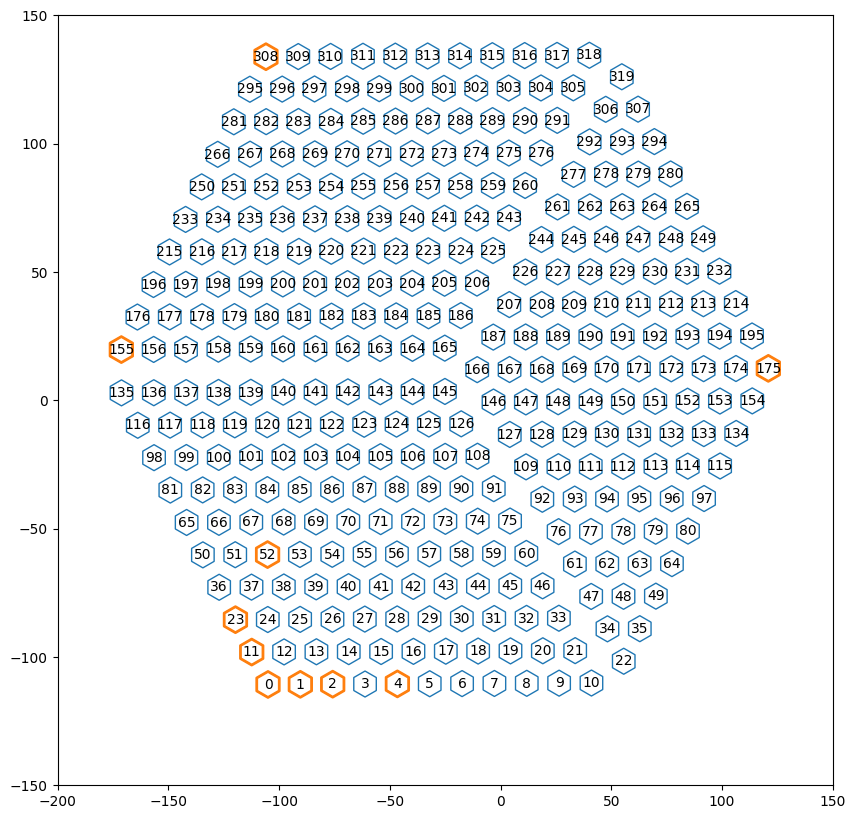

In [15]:
plt.figure(figsize=(10, 10))
plt.scatter(
    meta.antpos_enu[:, 0],
    meta.antpos_enu[:, 1],
    marker="h",
    color="none",
    lw=1,
    edgecolor="C0",
    s=350,
)

ants_to_highlight = sorted(set(sum(antpairs, start=())))
thispos = meta.antpos_enu[ants_to_highlight]

# thispos = meta.antpos_enu[blidx]
plt.scatter(
    thispos[:, 0], thispos[:, 1], marker="h", color="none", lw=2, edgecolor="C1", s=350
)

for i, pos in enumerate(meta.antpos_enu):
    if -200 < pos[0] < 150 and -150 < pos[1] < 150:
        plt.text(pos[0], pos[1], str(i), ha="center", va="center")

plt.xlim(-200, 150)
plt.ylim(-150, 150)

In [16]:
polidx = [meta.pols.index("ee"), meta.pols.index("nn")]

In [17]:
polidx

[0, 3]

In [18]:
pols = ["ee", "nn"]

In [19]:
meta.Ntimes * meta.Nbls * 2 * 16 / 1024**3

3.404560089111328

In [23]:
track?

Signature:
track(
    sequence: 'Iterable[ProgressType]',
    description: 'str' = 'Working...',
    total: 'Optional[float]' = None,
    completed: 'int' = 0,
    auto_refresh: 'bool' = True,
    console: 'Optional[Console]' = None,
    transient: 'bool' = False,
    get_time: 'Optional[Callable[[], float]]' = None,
    refresh_per_second: 'float' = 10,
    style: 'StyleType' = 'bar.back',
    complete_style: 'StyleType' = 'bar.complete',
    finished_style: 'StyleType' = 'bar.finished',
    pulse_style: 'StyleType' = 'bar.pulse',
    update_period: 'float' = 0.1,
    disable: 'bool' = False,
    show_speed: 'bool' = True,
) -> 'Iterable[ProgressType]'
Docstring:
Track progress by iterating over a sequence.

You can also track progress of an iterable, which might require that you additionally specify ``total``.

Args:
    sequence (Iterable[ProgressType]): Values you wish to iterate over and track progress.
    description (str, optional): Description of task show next to progress bar

In [ ]:
%%time

all_data = [
    np.zeros((meta.Ntimes, len(antpairs), 150, 2), dtype=complex) for _ in freq_chunks
]
freqs = [np.zeros(150) for _ in freq_chunks]

for ichunk, fchunk in enumerate(freq_chunks):
    for ffidx, fidx in track(enumerate(range(fchunk[0], fchunk[1])), total=fchunk[1] - fchunk[0]):
        fl = pth / f"fch{fidx:>04}_chunk00000.uvh5"

        if not fl.exists():
            break

        for iap, _idx in enumerate(blidx):
            slc = slice(_idx, None, meta.Nbls)

            with h5py.File(fl, "r") as _fl:
                all_data[ichunk][:, iap, ffidx, :] = _fl["Data"]["visdata"][
                    slc, 0, polidx
                ]
                freqs[ichunk][ffidx] = _fl["Header"]["freq_array"][0]

Working... ━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   6% -:--:--

In [25]:
%%time 
with h5py.File("../fch0000_chunk00000.uvh5", 'r') as fl:
    print(np.sum(fl['Data']['visdata']))

(475117809.92572284+15843488.835693555j)
CPU times: user 2.74 s, sys: 9.81 s, total: 12.5 s
Wall time: 2min 58s


## WaterFalls

In [ ]:
def plot_multibl_waterfall(freqs, all_data, pols=(0, 1)):
    fig, ax = plt.subplots(
        len(pols) * 2,
        len(blidx),
        constrained_layout=True,
        figsize=(12, len(pols) * 2 * 3),
        sharex=True,
        sharey=True,
        gridspec_kw={"hspace": 0, "wspace": 0},
    )

    extent = (
        freqs[0] / 1e6,
        freqs[-1] / 1e6,
        meta.lsts[0] * 12 / np.pi,
        meta.lsts[meta.Ntimes - 1] * 12 / np.pi,
    )
    amp_clim = (np.min(np.abs(all_data)), np.max(np.abs(all_data)))
    for j, bl in enumerate(antpairs):
        ax[0, j].set_title(bl)
        for ipol, pol in enumerate(pols):
            phs_img = ax[ipol, j].imshow(
                np.angle(all_data[:, j, :, pol]),
                cmap="twilight",
                aspect="auto",
                extent=extent,
                clim=(-np.pi, np.pi),
            )
            amp_img = ax[ipol + len(pols), j].imshow(
                np.abs(all_data[:, j, :, pol]),
                cmap="magma",
                aspect="auto",
                extent=extent,
                clim=amp_clim,
            )

    for i in range(len(pols) * 2):
        ax[i, 0].set_ylabel("LST [hr]")

    fig.colorbar(phs_img, ax=ax[: len(pols)])
    fig.colorbar(amp_img, ax=ax[len(pols) :])

    # ax[0, -1].text(1, 0.9,"xx phase",  transform=ax[0, -1].transAxes )
    # ax[1, -1].text(1, 0.9,"yy phase", transform=ax[1, -1].transAxes)
    # ax[2, -1].text(1, 0.9,"xx amp",transform=ax[2, -1].transAxes)
    # ax[3, -1].text(1, 0.9,"yy amp",transform=ax[3, -1].transAxes)

In [ ]:
plot_multibl_waterfall(freqs[0], all_data[0], pols=(0,))
plt.suptitle("xx pol")

In [ ]:
plot_multibl_waterfall(freqs[0], all_data[0], pols=(1,))
plt.suptitle("yy pol")

In [ ]:
plot_multibl_waterfall(freqs[1], all_data[1], pols=(0,))
plt.suptitle("xx")

In [ ]:
plot_multibl_waterfall(freqs[1], all_data[1], pols=(1,))
plt.suptitle("yy")

## Frequency-Based Inspection


In [ ]:
def get_delayspec(freqs: np.ndarray, data: np.ndarray):
    power = (
        np.abs(
            np.fft.fftshift(
                np.fft.fft(
                    data * blackmanharris(data.shape[-2])[None, None, :, None] ** 2,
                    axis=-2,
                )
            )
        )
        ** 2
    )
    delays = np.fft.fftshift(np.fft.fftfreq(data.shape[-2], d=freqs[1] - freqs[0]))
    return power, delays * 1e9

In [ ]:
fig, ax = plt.subplots(2, 2, sharex=True, constrained_layout=True, figsize=(12, 4))

power0, tau0 = get_delayspec(freqs[0], all_data[0])
power1, tau1 = get_delayspec(freqs[1], all_data[1])

for i, _p in enumerate(antpairs):
    for pol in (0, 1):
        # pk, tau = get_delayspec(freqs[0], all_data[0][:, i, :, pol])
        ax[0, pol].plot(tau0, power0[0, i, :, pol], color="k")
        ax[0, pol].plot(tau0, power0[8000, i, :, pol], color="r")

        ax[1, pol].plot(tau1, power1[0, i, :, pol], color="k")
        ax[1, pol].plot(tau1, power1[8000, i, :, pol], color="r")

    # ax.set_ylabel(str(p))
ax[0, 0].set_yscale("log")
ax[1, 0].set_yscale("log")
ax[0, 1].set_yscale("log")
ax[1, 1].set_yscale("log")


ax[1, 0].set_xlabel("Delay [ns]")
ax[1, 1].set_xlabel("Delay [ns]")
ax[0, 0].set_title("xx")
ax[0, 0].set_ylabel("Low Band")

ax[0, 1].set_title("yy")
ax[1, 0].set_ylabel("Mid Band")

## Time-Based Inspection

In [ ]:
def get_frspec(freqs: np.ndarray, data: np.ndarray):
    power = (
        np.abs(
            np.fft.fftshift(
                np.fft.fft(
                    data * blackmanharris(data.shape[0])[:, None, None, None] ** 2,
                    axis=0,
                )
            )
        )
        ** 2
    )
    delays = np.fft.fftshift(np.fft.fftfreq(data.shape[0], d=meta.integration_time[0]))
    return power, delays

In [ ]:
frspec0, frs0 = get_frspec(freqs[0], all_data[0])
frspec1, frs1 = get_frspec(freqs[1], all_data[1])

In [ ]:
fig, ax = plt.subplots(2, 2, sharex=True, constrained_layout=True, figsize=(12, 4))

for i, _p in enumerate(antpairs):
    for pol in (0, 1):
        # pk, tau = get_delayspec(freqs[0], all_data[0][:, i, :, pol])
        ax[0, pol].plot(frs0 * 1e3, frspec0[:, i, 75, pol], color="k")

        ax[1, pol].plot(frs1 * 1e3, frspec1[:, i, 75, pol], color="k")

    # ax.set_ylabel(str(p))
ax[0, 0].set_yscale("log")
ax[1, 0].set_yscale("log")
ax[0, 1].set_yscale("log")
ax[1, 1].set_yscale("log")


ax[1, 0].set_xlabel("Fringe-Rate [mHz]")
ax[1, 1].set_xlabel("Fringe-Rate [mHz]")
ax[0, 0].set_title("xx")
ax[0, 0].set_ylabel("Low Band")

ax[0, 1].set_title("yy")
ax[1, 0].set_ylabel("Mid Band")


# fig, ax = plt.subplots(2,2, sharex=True, sharey=True,
# for i, p in enumerate(antpairs):
#     for pol in (0, ):
#         plt.plot(frs*1e3, frspec[:, i, 0,pol], color='k')
#         plt.plot(frs*1e3, frspec[:, i, 100,pol], color='r')
# plt.yscale('log')
# plt.xlim(-10,10)

In [ ]:
fig, ax = plt.subplots(2, 2, sharex=True, constrained_layout=True, figsize=(12, 4))

for i, _p in enumerate(antpairs):
    for pol in (0, 1):
        # pk, tau = get_delayspec(freqs[0], all_data[0][:, i, :, pol])
        ax[0, pol].plot(frs0 * 1e3, frspec0[:, i, 75, pol], color="k")

        ax[1, pol].plot(frs1 * 1e3, frspec1[:, i, 75, pol], color="k")

    # ax.set_ylabel(str(p))
ax[0, 0].set_yscale("log")
ax[1, 0].set_yscale("log")
ax[0, 1].set_yscale("log")
ax[1, 1].set_yscale("log")


ax[1, 0].set_xlabel("Fringe-Rate [mHz]")
ax[1, 1].set_xlabel("Fringe-Rate [mHz]")
ax[0, 0].set_title("xx")
ax[0, 0].set_ylabel("Low Band")

ax[0, 1].set_title("yy")
ax[1, 0].set_ylabel("Mid Band")

for axx in ax.flatten():
    axx.set_xlim(-10, 10)